iteration 21 results |k={K}
Log Likelihood: 518887.09
silhoutte: 0.171
cluster profile(means,original scale) - Iteration 21 GaussianMixture(RobustScaler) Full, labels):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
54459,19.356715498995722,1.0,20.482215725023543,19.356715498995722,0.359,0.2517956267548057,0.5116856821443649
7514,111.64534275294292,3.711,22.14373831065149,29.648498357457534,0.296,0.3040935962774829,0.5806252815005054
12889,57.88618261495446,2.0,21.46362484343309,28.94309130747723,0.31,0.2948154071449746,0.5595761539435289
33138,57.45699844024085,1.0,21.97098728419222,57.45699844024085,0.283,0.3353181819698642,0.5821076751430679


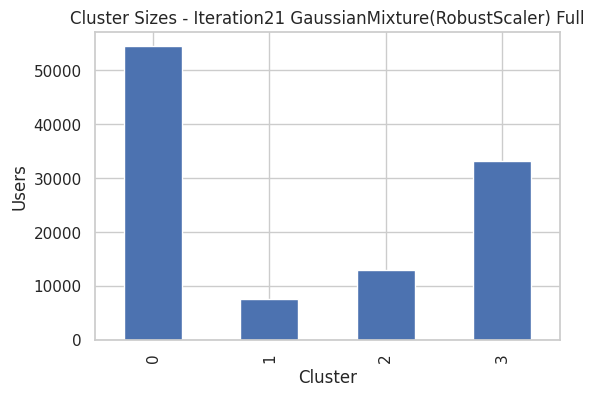

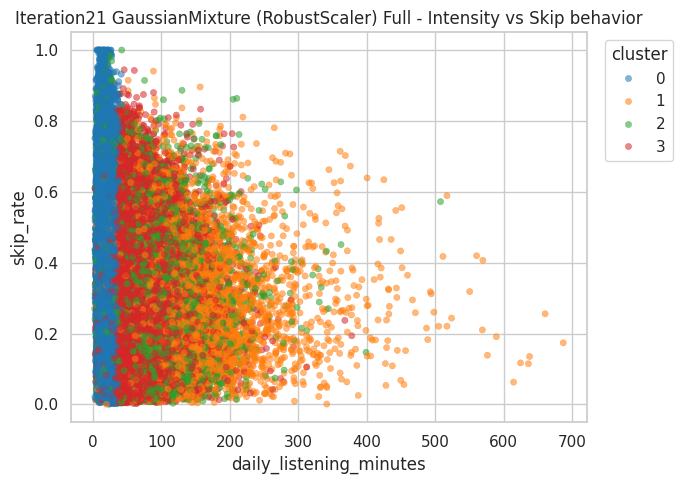

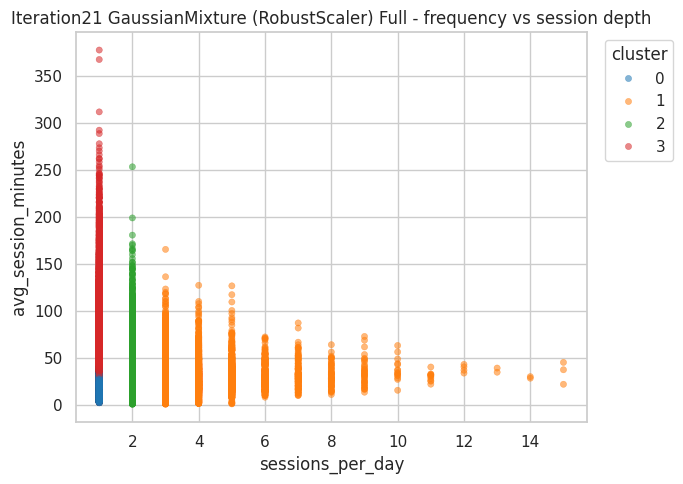

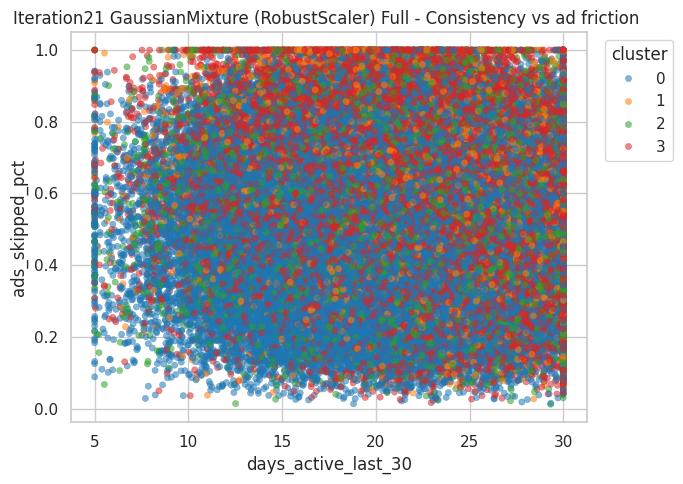

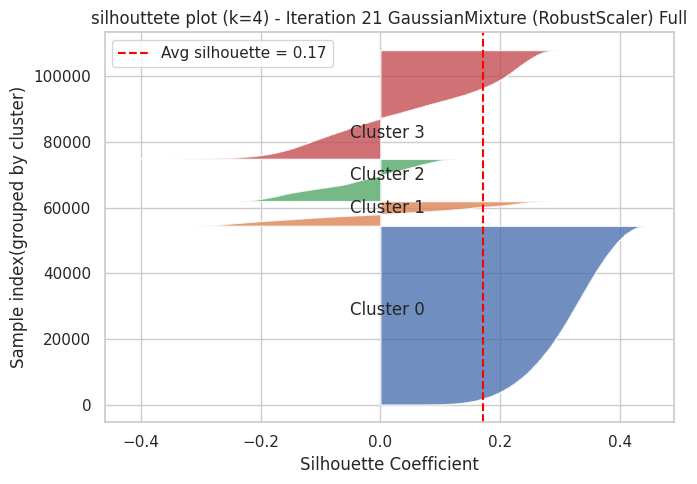

In [0]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score , silhouette_samples
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
spotify_user_behavior =spark.table("spotify.spotify_user_behavior").toPandas()
CLUSTER_FEATURES_V1=[
    "daily_listening_minutes",
    "sessions_per_day",
    "days_active_last_30",
    "avg_session_minutes",
    "skip_rate",
    "liked_songs_pct",
    "ads_skipped_pct",
]

base = spotify_user_behavior[["user_id"]+CLUSTER_FEATURES_V1].copy()
K=4
X21=base[CLUSTER_FEATURES_V1].copy()
Robust=RobustScaler()
X21_Robust=Robust.fit_transform(X21)
X21=pd.DataFrame(X21_Robust,columns=CLUSTER_FEATURES_V1,index=base.index)
gmm21 = GaussianMixture(n_components=K ,random_state=42, covariance_type="full" ,n_init=5,max_iter=200)

labels21 = gmm21.fit_predict(X21)
log_likelihood21 = gmm21.score(X21) * len(X21)
sil_avg_21=silhouette_score(X21,labels21)
base_iter21=base.copy()
base_iter21["cluster"]=labels21
print("iteration 21 results |k={K}")
print("Log Likelihood:",round(log_likelihood21,2))
print("silhoutte:",round(sil_avg_21,3))
sizes21=base_iter21["cluster"].value_counts().sort_index()
means21=(
    base_iter21
    .groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)
profile21=means21.copy()
profile21.insert(0,"cluster_size",sizes21)
print("cluster profile(means,original scale) - Iteration 21 GaussianMixture(RobustScaler) Full, labels):")
display(profile21)

plt.figure(figsize=(6,4))
base_iter21["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration21 GaussianMixture(RobustScaler) Full")
plt.xlabel("Cluster")
plt.ylabel("Users")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter21,
    x="daily_listening_minutes",
    y="skip_rate",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration21 GaussianMixture (RobustScaler) Full - Intensity vs Skip behavior")
plt.legend(title="cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter21,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration21 GaussianMixture (RobustScaler) Full - frequency vs session depth")
plt.legend(title="cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter21,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration21 GaussianMixture (RobustScaler) Full - Consistency vs ad friction ")
plt.legend(title="cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()

sil_values_21=silhouette_samples(X21,labels21)
plt.figure(figsize=(7,5))
y_lower=0
vals0=sil_values_21[labels21==0]
vals0.sort()
size0=vals0.shape[0]
y_upper=y_lower+size0
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals0,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size0,
    "Cluster 0"
)
y_lower=y_upper

vals1=sil_values_21[labels21==1]
vals1.sort()
size1=vals1.shape[0]
y_upper=y_lower+size1
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals1,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size1,
    "Cluster 1"
)
y_lower=y_upper

vals2=sil_values_21[labels21==2]
vals2.sort()    
size2=vals2.shape[0]
y_upper=y_lower+size2
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals2,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size2,
    "Cluster 2"
)
y_lower=y_upper    

vals3=sil_values_21[labels21==3]
vals3.sort()    
size3=vals3.shape[0]
y_upper=y_lower+size3
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals3,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size2,
    "Cluster 3"
)
y_lower=y_upper   
plt.axvline(
    x=sil_avg_21,
    color="red",
    linestyle="--",
    label=f"Avg silhouette = {sil_avg_21:.2f}"
)
plt.title("silhouttete plot (k=4) - Iteration 21 GaussianMixture (RobustScaler) Full")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample index(grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()
